In [1]:
# Install if needed
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("scraped_data_kaggle.csv")

# Preview
df.head()

,BPrev,BStreak,B_Age,B_Height,B_HomeTown,B_ID,B_Location,B_Name,B_Weight,B__Round1_Grappling_Reversals_Landed,B__Round1_Grappling_Standups_Landed,B__Round1_Grappling_Submissions_Attempts,B__Round1_Grappling_Takedowns_Attempts,B__Round1_Grappling_Takedowns_Landed,B__Round1_Strikes_Body Significant Strikes_Attempts,B__Round1_Strikes_Body Significant Strikes_Landed,B__Round1_Strikes_Body Total Strikes_Attempts,B__Round1_Strikes_Body Total Strikes_Landed,B__Round1_Strikes_Clinch Body Strikes_Attempts,B__Round1_Strikes_Clinch Body Strikes_Landed,B__Round1_Strikes_Clinch Head Strikes_Attempts,B__Round1_Strikes_Clinch Head Strikes_Landed,B__Round1_Strikes_Clinch Leg Strikes_Attempts,B__Round1_Strikes_Clinch Leg Strikes_Landed,B__Round1_Strikes_Clinch Significant Kicks_Attempts,B__Round1_Strikes_Clinch Significant Kicks_Landed,B__Round1_Strikes_Clinch Significant Punches_Attempts,B__Round1_Strikes_Clinch Significant Punches_Landed,B__Round1_Strikes_Clinch Significant Strikes_Attempts,B__Round1_Strikes_Clinch Significant Strikes_Landed,B__Round1_Strikes_Clinch Total Strikes_Attempts,B__Round1_Strikes_Clinch Total Strikes_Landed,B__Round1_Strikes_Distance Body Kicks_Attempts,B__Round1_Strikes_Distance Body Kicks_Landed,B__Round1_Strikes_Distance Body Punches_Attempts,B__Round1_Strikes_Distance Body Punches_Landed,B__Round1_Strikes_Distance Body Strikes_Attempts,B__Round1_Strikes_Distance Body Strikes_Landed,B__Round1_Strikes_Distance Head Kicks_Attempts,B__Round1_Strikes_Distance Head Kicks_Landed,...,R__Round5_Strikes_Ground Significant Punches_Attempts,R__Round5_Strikes_Ground Significant Punches_Landed,R__Round5_Strikes_Ground Significant Strikes_Attempts,R__Round5_Strikes_Ground Significant Strikes_Landed,R__Round5_Strikes_Ground Total Strikes_Attempts,R__Round5_Strikes_Ground Total Strikes_Landed,R__Round5_Strikes_Head Significant Strikes_Attempts,R__Round5_Strikes_Head Significant Strikes_Landed,R__Round5_Strikes_Head Total Strikes_Attempts,R__Round5_Strikes_Head Total Strikes_Landed,R__Round5_Strikes_Kicks_Attempts,R__Round5_Strikes_Kicks_Landed,R__Round5_Strikes_Knock Down_Landed,R__Round5_Strikes_Leg Total Strikes_Attempts,R__Round5_Strikes_Leg Total Strikes_Landed,R__Round5_Strikes_Legs Significant Strikes_Attempts,R__Round5_Strikes_Legs Significant Strikes_Landed,R__Round5_Strikes_Legs Total Strikes_Attempts,R__Round5_Strikes_Legs Total Strikes_Landed,R__Round5_Strikes_Punches_Attempts,R__Round5_Strikes_Punches_Landed,R__Round5_Strikes_Significant Strikes_Attempts,R__Round5_Strikes_Significant Strikes_Landed,R__Round5_Strikes_Total Strikes_Attempts,R__Round5_Strikes_Total Strikes_Landed,R__Round5_TIP_Back Control Time,R__Round5_TIP_Clinch Time,R__Round5_TIP_Control Time,R__Round5_TIP_Distance Time,R__Round5_TIP_Ground Control Time,R__Round5_TIP_Ground Time,R__Round5_TIP_Guard Control Time,R__Round5_TIP_Half Guard Control Time,R__Round5_TIP_Misc. Ground Control Time,R__Round5_TIP_Mount Control Time,R__Round5_TIP_Neutral Time,R__Round5_TIP_Side Control Time,R__Round5_TIP_Standing Time,winby,winner
0,0,0,38.0,193.0,Hounslow England,808,Amsterdam The Netherlands,Alistair Overeem,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEC,blue
1,0,0,36.0,172.0,"Chicago, Illinois United States",1054,"Chicago, Illinois United States",Ricardo Lamas,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEC,red
2,0,0,39.0,167.0,"Isla Vista , California USA",959,"Sacramento, California USA",Urijah Faber,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [8]:
# De-fragment DataFrame (fix warning)
df = df.copy()

# Apply cleaning
df['clean_text'] = df[text_column].fillna('').apply(clean_text)

# Preview
print(df[[text_column, 'clean_text']].head())

                        B_HomeTown                     clean_text
0                 Hounslow England               hounslow england
1  Chicago, Illinois United States  chicago illinois united state
2      Isla Vista , California USA      isla vista california usa
3                San Diego, CA USA               san diego ca usa
4              Southampton England            southampton england


In [9]:
df = df.copy()
df['clean_text'] = df[text_column].fillna('').apply(clean_text)

In [10]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

print(X.shape)

(2318, 886)


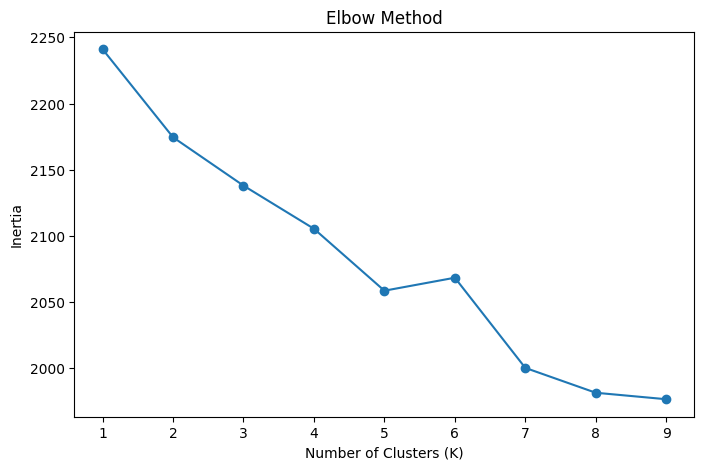

In [11]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
k = 5  # choose based on elbow

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

df.head()

,BPrev,BStreak,B_Age,B_Height,B_HomeTown,B_ID,B_Location,B_Name,B_Weight,B__Round1_Grappling_Reversals_Landed,B__Round1_Grappling_Standups_Landed,B__Round1_Grappling_Submissions_Attempts,B__Round1_Grappling_Takedowns_Attempts,B__Round1_Grappling_Takedowns_Landed,B__Round1_Strikes_Body Significant Strikes_Attempts,B__Round1_Strikes_Body Significant Strikes_Landed,B__Round1_Strikes_Body Total Strikes_Attempts,B__Round1_Strikes_Body Total Strikes_Landed,B__Round1_Strikes_Clinch Body Strikes_Attempts,B__Round1_Strikes_Clinch Body Strikes_Landed,B__Round1_Strikes_Clinch Head Strikes_Attempts,B__Round1_Strikes_Clinch Head Strikes_Landed,B__Round1_Strikes_Clinch Leg Strikes_Attempts,B__Round1_Strikes_Clinch Leg Strikes_Landed,B__Round1_Strikes_Clinch Significant Kicks_Attempts,B__Round1_Strikes_Clinch Significant Kicks_Landed,B__Round1_Strikes_Clinch Significant Punches_Attempts,B__Round1_Strikes_Clinch Significant Punches_Landed,B__Round1_Strikes_Clinch Significant Strikes_Attempts,B__Round1_Strikes_Clinch Significant Strikes_Landed,B__Round1_Strikes_Clinch Total Strikes_Attempts,B__Round1_Strikes_Clinch Total Strikes_Landed,B__Round1_Strikes_Distance Body Kicks_Attempts,B__Round1_Strikes_Distance Body Kicks_Landed,B__Round1_Strikes_Distance Body Punches_Attempts,B__Round1_Strikes_Distance Body Punches_Landed,B__Round1_Strikes_Distance Body Strikes_Attempts,B__Round1_Strikes_Distance Body Strikes_Landed,B__Round1_Strikes_Distance Head Kicks_Attempts,B__Round1_Strikes_Distance Head Kicks_Landed,...,R__Round5_Strikes_Ground Significant Strikes_Attempts,R__Round5_Strikes_Ground Significant Strikes_Landed,R__Round5_Strikes_Ground Total Strikes_Attempts,R__Round5_Strikes_Ground Total Strikes_Landed,R__Round5_Strikes_Head Significant Strikes_Attempts,R__Round5_Strikes_Head Significant Strikes_Landed,R__Round5_Strikes_Head Total Strikes_Attempts,R__Round5_Strikes_Head Total Strikes_Landed,R__Round5_Strikes_Kicks_Attempts,R__Round5_Strikes_Kicks_Landed,R__Round5_Strikes_Knock Down_Landed,R__Round5_Strikes_Leg Total Strikes_Attempts,R__Round5_Strikes_Leg Total Strikes_Landed,R__Round5_Strikes_Legs Significant Strikes_Attempts,R__Round5_Strikes_Legs Significant Strikes_Landed,R__Round5_Strikes_Legs Total Strikes_Attempts,R__Round5_Strikes_Legs Total Strikes_Landed,R__Round5_Strikes_Punches_Attempts,R__Round5_Strikes_Punches_Landed,R__Round5_Strikes_Significant Strikes_Attempts,R__Round5_Strikes_Significant Strikes_Landed,R__Round5_Strikes_Total Strikes_Attempts,R__Round5_Strikes_Total Strikes_Landed,R__Round5_TIP_Back Control Time,R__Round5_TIP_Clinch Time,R__Round5_TIP_Control Time,R__Round5_TIP_Distance Time,R__Round5_TIP_Ground Control Time,R__Round5_TIP_Ground Time,R__Round5_TIP_Guard Control Time,R__Round5_TIP_Half Guard Control Time,R__Round5_TIP_Misc. Ground Control Time,R__Round5_TIP_Mount Control Time,R__Round5_TIP_Neutral Time,R__Round5_TIP_Side Control Time,R__Round5_TIP_Standing Time,winby,winner,clean_text,cluster
0,0,0,38.0,193.0,Hounslow England,808,Amsterdam The Netherlands,Alistair Overeem,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEC,blue,hounslow england,0
1,0,0,36.0,172.0,"Chicago, Illinois United States",1054,"Chicago, Illinois United States",Ricardo Lamas,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEC,red,chicago illinois united state,3
2,0,0,39.0,167.0,"Isla Vista , California USA",959,"Sacramento, California USA",Urijah Faber,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,N

In [13]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_terms = [terms[ind] for ind in center.argsort()[-10:]]
    
    print(f"\nCluster {i}:")
    print(", ".join(top_terms))


Cluster 0:
south, republic, australia, mexico, canada, dagestan, england, poland, japan, russia

Cluster 1:
nilopolis, brasil, nova, friburgo, niteroi, tres, brazil, de, janeiro, rio

Cluster 2:
horizonte, manaus, bahia, salvador, gerais, mina, amazona, sao, paulo, brazil

Cluster 3:
wisconsin, hawaii, texas, washington, illinois, york, new, california, united, state

Cluster 4:
florida, texas, pennsylvania, new, diego, ohio, ca, san, california, usa


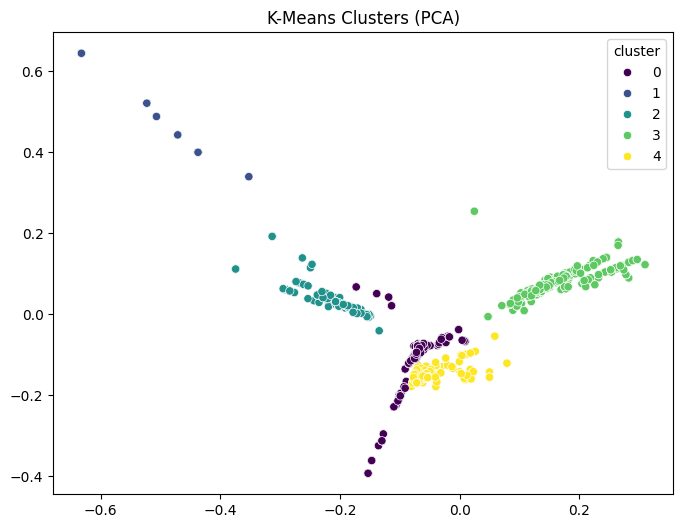

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], palette='viridis')
plt.title("K-Means Clusters (PCA)")
plt.show()

In [15]:
df.to_csv("clustered_output.csv", index=False)